#Customer Complaint Analysis: Topic Modeling for Banking

## Project Overview

**Objective:** Perform topic modeling on customer complaints data across multple banking channels to uncover hidden issues and common themes, ultimately improving customer experience.

### What is Topic modeling?
Topic Modeling is an **unsupervised machine learning technique** that automatically discovers abstract "topics" that occur in a collection of documents. Think of it as automaticaaly organizing thousands of complaints into meaningful groups based on what they're actually talking about.

###Why this matters for Banking
- **Identify Pain Points:** Discover what customers complain about most.
- **Resource Allocation:** Know which departments need more support.
- **Proactive Improvements:** Fix issues before they become widespread.
- **Customer Retention:** Address concerns to reduce churn.

### Methods We'll Use
1. **BERTopic** - A modern, transformer-based topic modeling approach that understands context
2. **LDA (Latent Dirichlet Allocation)** - A traditional probabilistic approach for comparison.

### References
- [Topic Modeling: BERTopic vs LDA Explained](https://medium.com/@maheera_amjad/topic-modeling-in-nlp-lda-vs-bertopic-explained-31e4fbe153dd)
- [Topic Modeling on Customer Reviews using BERTopic](https://towardsai.net/p/l/topic-modeling-on-customer-reviews-using-bertopic-and-llama2)
- [NLP in Banking Customer Complaints](https://www.johnsnowlabs.com/examining-the-impact-of-nlp-in-financial-services/)

## Cell 1: Install Required Libraries

**What this does:** Installs all the Python packages we need for this analysis.

**Key Libraries:**
- `pandas` - Data manipulation and analysis
- `bertopic` - Modern topic modeling using transformers
- `nltk` - Natural Language Toolkit for text preprocessing
- `plotly` - Interactive visualizations
- `wordcloud` - Visual representation of frequent words
- `kaleido` - Converts plotly figures into static image files


In [2]:
# Install required packages
!pip install -q pandas numpy matplotlib seaborn plotly wordcloud
!pip install -q nltk scikit-learn
!pip install -q bertopic
!pip install -q sentence-transformers
!pip install -q kaleido

print("All packages installed successfully!")


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


All packages installed successfully!



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Cell 2: Import Libraries and Configure Settings

**What this does:** Loads all the libraries into memory and configures display settings.

**Why we need each:**
- `pandas` - Think of it as Excel for Python, handles our data tables
- `numpy` - Mathematical operations on arrays
- `matplotlib/seaborn` - Create charts and graphs
- `plotly` - Interactive charts you can hover over
- `nltk` - Tools for processing human language
- `re` - Regular expressions for pattern matching in text

In [1]:
#Core data manipulation
import pandas as pd
import numpy as np

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud

#NLP and Text Processing
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

#Topic Modeling
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

#Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

#Download NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

#Display settings
#pd.set_option('display.max_columns', None)
#pd.set_option('display.max_colwidth', 100)
#plt.style.use('seaborn-v0_8-whitegrid')

print("All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")

All libraries imported successfully!
Pandas version: 2.3.3


## Cell 3: Load and Preview the Data

**What this does:** Reads our CSV file containing customer complaints into a pandas DataFrame.

**Dataset Structure:**
- `case_number` - Unique identifier for each complaint
- `date_created` - When the complaint was logged
- `category` - The banking channel/department (e.g., Mobile Banking, Loans)
- `description` - The actual complaint text

**Note:** Personal information has been masked with placeholders like [NAME], [ACCOUNT], [PHONE] to protect customer privacy.

In [7]:
# Load the dataset
# For Colab: Upload your file or mount Google Drive
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('../data/project1_complaints_dataset.csv')

In [8]:
# Convert date column to datetime format
df['date_created'] = pd.to_datetime(df['date_created'])

# Basic information about the dataset
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nTotal Complaints: {len(df):,}")

print(f"Date Range: {df['date_created'].min().date()} to {df['date_created'].max().date()}")
print(f"Number of Categories: {df['category'].nunique()}")
print(f"Missing Descriptions: {df['description'].isnull().sum()}")



DATASET OVERVIEW

Total Complaints: 16,855
Date Range: 2025-04-01 to 2025-06-29
Number of Categories: 58
Missing Descriptions: 10


In [ ]:
print("\n" + "=" * 60)
print("FIRST 5 COMPLAINTS")
print("=" * 60)
df.head()


FIRST 5 COMPLAINTS


,case_number,date_created,category,description
0,49921764,2025-05-08 11:14:34,Dispute,Client says there is a reduction of [AMOUNT:USD:<100] off his account that he doesn't understand...
1,52457154,2025-06-26 12:09:37,Dispute,Client is requesting to have the liens on his account dropped so that he can access his funds. a...
2,52549950,2025-06-28 14:48:50,Dispute,"[NAME],\n\nPlease drop lien as per attached receipt. [NAME] performed a visa transaction it was ..."
3,49985363,2025-05-10 10:01:30,Fraud Scam,[ACCOUNT] [NAME] \nCustomer has raised a complaint of a fraudulent transaction on her account th...
4,52497668,2025-06-27 10:26:54,Dispute,"hello Team,\nkindly assist investigate instruction on customer account from [DATE:2025-03] to [D..."


## Cell 4: Analyze Category Distribution

**What this does:** Identifies the most common categories of complaints to understand which areas are generating the most feedback.

**Why this matters:** Helps in prioritizing resources and understanding key problem areas.

### All Complaint Categories and Their Counts

In [ ]:
# Calculate counts for all categories
all_category_counts = df['category'].value_counts()

print("All complaint categories and their counts:")
print(all_category_counts.to_string())

All complaint categories and their counts:
category
Mobile Banking                        5428
Account Management                    2367
Agent Banking                         1150
Loans                                  928
Internet Banking                       821
Dispute                                765
ATM Operations                         760
Flexipay Wallet                        681
Debit Card                             527
Payments Processing                    382
Biller & Utility Payments              371
Flexipay Merchant                      326
Agent Banking?                         267
Smart APP                              241
Business Online                        206
CRB Disputes                           194
SMS Alerts                             157
Interest, Fees, and Other Charges      150
Enterprise Online                      142
Flexipay Anchor                        114
CDM Operations                         112
Enterprise online                      110
Pa

In [ ]:
# Calculate the most common categories
most_common_category = df['category'].value_counts().idxmax()
category_counts = df['category'].value_counts().head(10)

print(f"The most common complaint category is: {most_common_category}")
print("\nTop 10 complaint categories:")
print(category_counts.to_string())

The most common complaint category is: Mobile Banking

Top 10 complaint categories:
category
Mobile Banking         5428
Account Management     2367
Agent Banking          1150
Loans                   928
Internet Banking        821
Dispute                 765
ATM Operations          760
Flexipay Wallet         681
Debit Card              527
Payments Processing     382


Let's visualize the distribution of complaint categories to get a clearer picture.

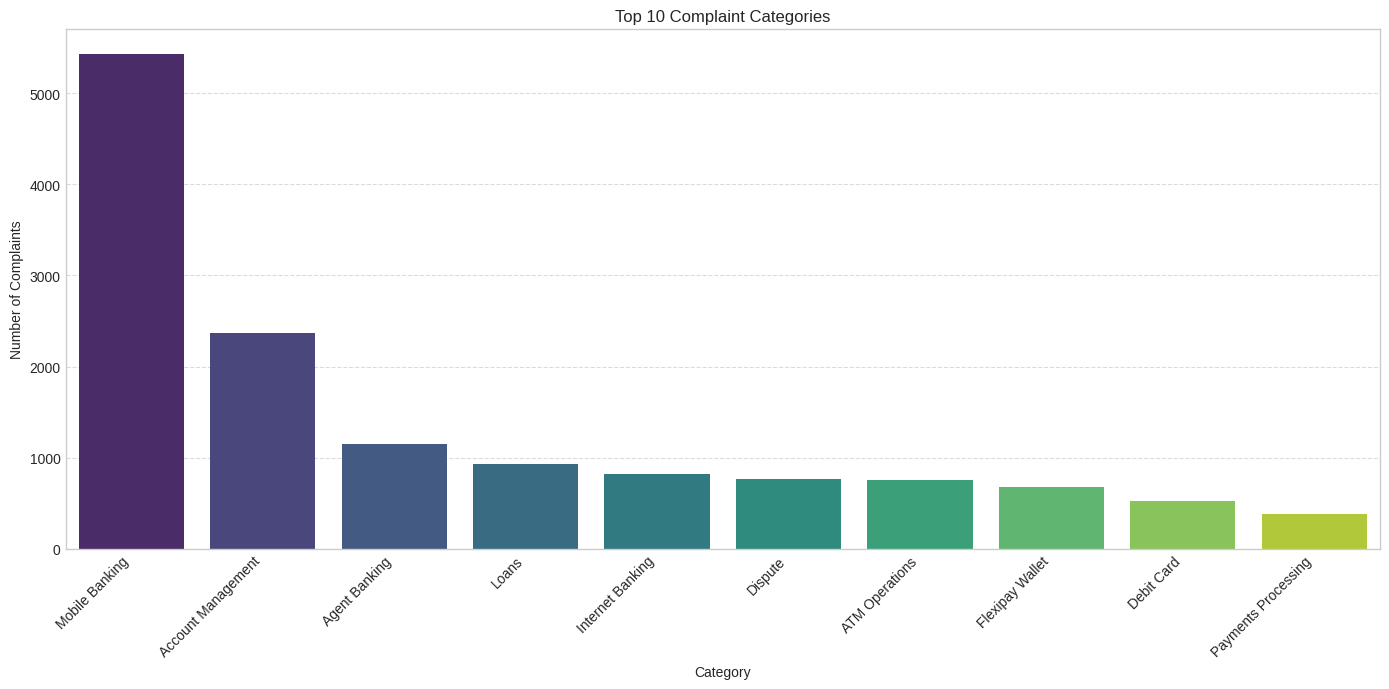

In [ ]:
plt.figure(figsize=(14, 7))
sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')
plt.title('Top 10 Complaint Categories')
plt.xlabel('Category')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Cell 5: Analyze Most Common Complaint Time

**What this does:** Extracts the hour from the `date_created` column to identify the most frequent hour for complaints.

**Why this matters:** Understanding peak complaint times can help in resource planning and staffing for customer service departments.

In [ ]:
# Extract temporal features
df['date'] = df['date_created'].dt.date
df['week'] = df['date_created'].dt.isocalendar().week
df['day_of_week'] = df['date_created'].dt.day_name()
df['hour'] = df['date_created'].dt.hour
df['month'] = df['date_created'].dt.month_name()

#Copying category_mapping from another cell to ensure it's available
category_mapping = {
    'Enterprise online': 'Enterprise Online',
    'Payments processing': 'Payments Processing',
    'Agent Banking?': 'Agent Banking',
    'SmartAPP': 'Smart APP',
    'Fraud/Scam': 'Fraud Scam',
    'Bussiness Online': 'Business Online',
    'Flexipay Merchants': 'Flexipay Merchant',
    'Interest/Fees/Charges': 'Interest, Fees, and Other Charges'
}

# Create 'category_clean' if it doesn't already exist in df
if 'category_clean' not in df.columns:
    df['category_clean'] = df['category'].replace(category_mapping)

# Daily complaint trend
daily_complaints = df.groupby('date').size().reset_index(name='count')
daily_complaints['date'] = pd.to_datetime(daily_complaints['date'])

# Create interactive time series plot
fig = make_subplots(rows=2, cols=2,
                    subplot_titles=('Daily Complaint Volume', 'Complaints by Day of Week',
                                   'Complaints by Hour of Day', 'Top Categories Over Time'),
                    specs=[[{"type": "scatter"}, {"type": "bar"}],
                           [{"type": "bar"}, {"type": "scatter"}]])

# Plot 1: Daily trend
fig.add_trace(go.Scatter(x=daily_complaints['date'], y=daily_complaints['count'],
                         mode='lines+markers', name='Daily Count',
                         line=dict(color='royalblue')), row=1, col=1)

# Plot 2: Day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = df['day_of_week'].value_counts().reindex(day_order)
fig.add_trace(go.Bar(x=dow_counts.index, y=dow_counts.values,
                     marker_color='steelblue', name='By Day'), row=1, col=2)

# Plot 3: Hour of day
hour_counts = df['hour'].value_counts().sort_index()
fig.add_trace(go.Bar(x=hour_counts.index, y=hour_counts.values,
                     marker_color='darkblue', name='By Hour'), row=2, col=1)

# Recalculate category_counts from the current df to ensure consistency
category_counts = df['category_clean'].value_counts()

# Plot 4: Top categories over time (weekly)
top_cats = category_counts.head(5).index.tolist()
for cat in top_cats:
    cat_weekly = df[df['category_clean'] == cat].groupby('week').size()
    fig.add_trace(go.Scatter(x=cat_weekly.index, y=cat_weekly.values,
                             mode='lines+markers', name=cat), row=2, col=2)

fig.update_layout(height=700, showlegend=True, title_text="Temporal Analysis of Complaints")
fig.update_xaxes(title_text="Date", row=1, col=1)
fig.update_xaxes(title_text="Day", row=1, col=2)
fig.update_xaxes(title_text="Hour", row=2, col=1)
fig.update_xaxes(title_text="Week Number", row=2, col=2)
#fig.write_image('output_temporal_analysis.png')
fig.show()

# Key insights
print("\n" + "=" * 60)
print("TEMPORAL INSIGHTS")
print("=" * 60)
print(f"\nBusiest Day: {dow_counts.idxmax()} ({dow_counts.max():,} complaints)")
print(f"Quietest Day: {dow_counts.idxmin()} ({dow_counts.min():,} complaints)")
print(f"\nPeak Hour: {hour_counts.idxmax()}:00 ({hour_counts.max():,} complaints)")
print(f"Quietest Hour: {hour_counts.idxmin()}:00 ({hour_counts.min():,} complaints)")



TEMPORAL INSIGHTS

Busiest Day: Wednesday (3,274 complaints)
Quietest Day: Sunday (866 complaints)

Peak Hour: 11:00 (1,601 complaints)
Quietest Hour: 2:00 (9 complaints)


In [ ]:
# Extract the hour from the 'date_created' column
df['complaint_hour'] = df['date_created'].dt.hour

# Calculate the most common hour for complaints
most_common_hour = df['complaint_hour'].mode()[0]
hour_counts = df['complaint_hour'].value_counts().sort_index()

print(f"The most common hour for complaints is: {most_common_hour:02d}:00 (24-hour format).")
print("\nCounts of complaints by hour:\n")
print(hour_counts.to_string())

The most common hour for complaints is: 11:00 (24-hour format).

Counts of complaints by hour:

complaint_hour
0       51
1       42
2        9
3       16
4       23
5       28
6       63
7      352
8      910
9     1445
10    1481
11    1601
12    1553
13    1335
14    1351
15    1373
16    1418
17    1067
18     993
19     659
20     446
21     313
22     205
23     121


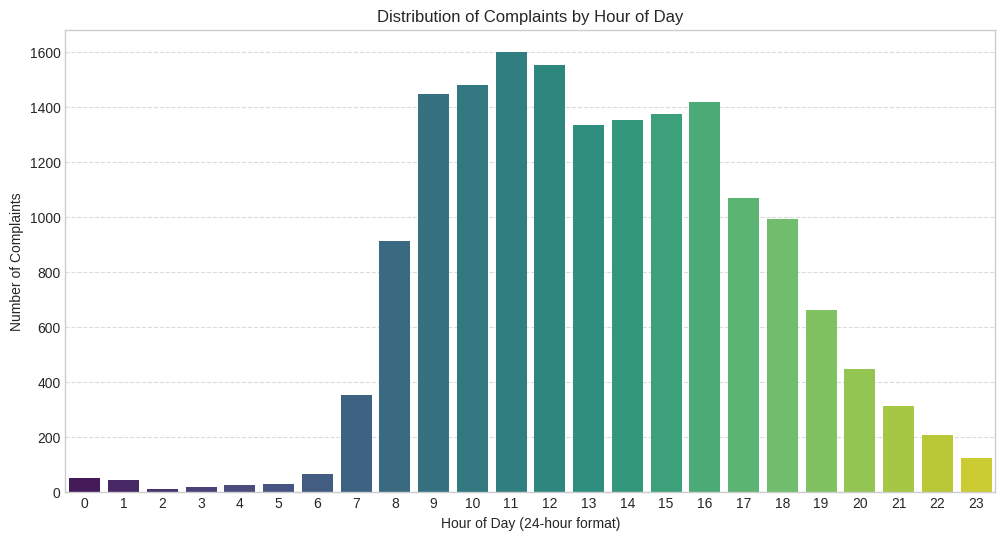

In [ ]:
# Visualize the distribution of complaints by hour
plt.figure(figsize=(12, 6))
sns.countplot(x='complaint_hour', data=df, palette='viridis')
plt.title('Distribution of Complaints by Hour of Day')
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Number of Complaints')
plt.xticks(range(0, 24)) # Ensure all hours are displayed on the x-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


---
## Cell 6: Complaint Text Analysis - Length and Patterns

**What this does:** Analyzes the characteristics of complaint text across categories.

**Business Insight:**
- Longer complaints may indicate more complex issues
- Categories with longer descriptions might need specialized handling
- Understanding text patterns helps with automation potential

Removed 10 rows with missing descriptions


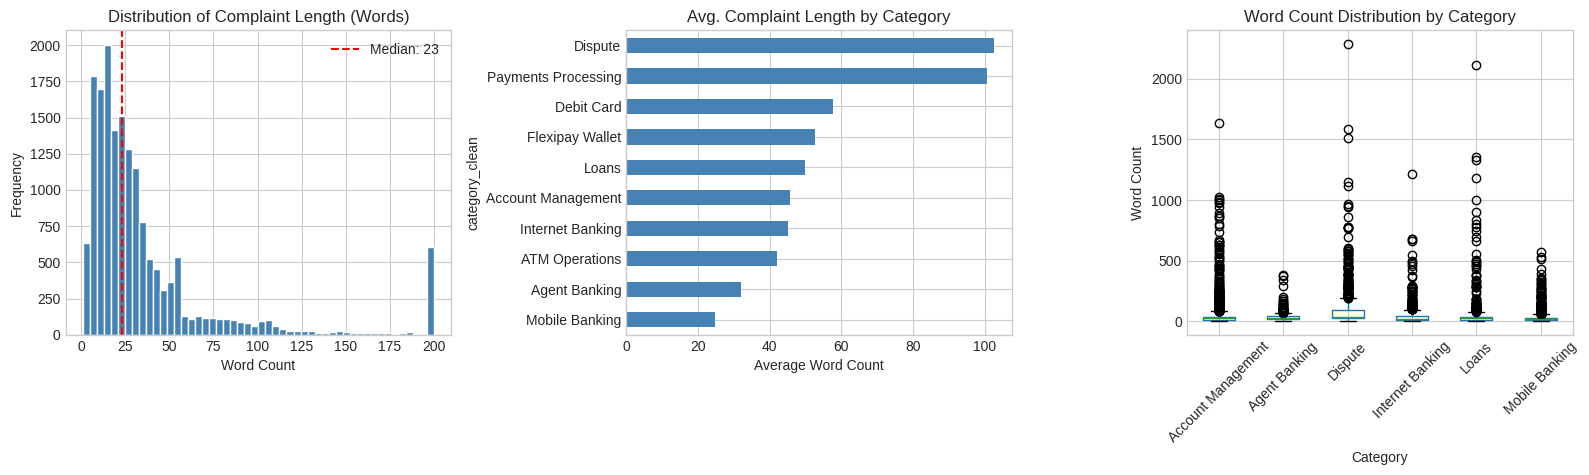


TEXT LENGTH STATISTICS

Average words per complaint: 46.2
Median words per complaint: 23
Shortest complaint: 1 words
Longest complaint: 2902 words


In [ ]:
# Remove rows with missing descriptions
df_clean = df.dropna(subset=['description']).copy()
print(f"Removed {len(df) - len(df_clean)} rows with missing descriptions")

# Standardize category names (fix case inconsistencies) - Copied from cell DaBxfYt0NRMA
category_mapping = {
    'Enterprise online': 'Enterprise Online',
    'Payments processing': 'Payments Processing',
    'Agent Banking?': 'Agent Banking',
    'SmartAPP': 'Smart APP',
    'Fraud/Scam': 'Fraud Scam',
    'Bussiness Online': 'Business Online',
    'Flexipay Merchants': 'Flexipay Merchant',
    'Interest/Fees/Charges': 'Interest, Fees, and Other Charges'
}
df_clean['category_clean'] = df_clean['category'].replace(category_mapping)

# Recalculate category_counts based on the cleaned categories in df_clean
category_counts = df_clean['category_clean'].value_counts()

# Calculate text statistics
df_clean['char_count'] = df_clean['description'].str.len()
df_clean['word_count'] = df_clean['description'].str.split().str.len()

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribution of word counts
axes[0].hist(df_clean['word_count'].clip(upper=200), bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(df_clean['word_count'].median(), color='red', linestyle='--', label=f'Median: {df_clean["word_count"].median():.0f}')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Complaint Length (Words)')
axes[0].legend()

# Average word count by top categories
top_cat_list = category_counts.head(10).index.tolist()
avg_words = df_clean[df_clean['category_clean'].isin(top_cat_list)].groupby('category_clean')['word_count'].mean().sort_values(ascending=True)
avg_words.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_xlabel('Average Word Count')
axes[1].set_title('Avg. Complaint Length by Category')

# Box plot of word counts for top categories
df_top_cats = df_clean[df_clean['category_clean'].isin(top_cat_list[:6])]
df_top_cats.boxplot(column='word_count', by='category_clean', ax=axes[2], rot=45)
axes[2].set_xlabel('Category')
axes[2].set_ylabel('Word Count')
axes[2].set_title('Word Count Distribution by Category')
plt.suptitle('')  # Remove automatic title

plt.tight_layout()
plt.show()

# Statistics
print("\n" + "=" * 60)
print("TEXT LENGTH STATISTICS")
print("=" * 60)
print(f"\nAverage words per complaint: {df_clean['word_count'].mean():.1f}")
print(f"Median words per complaint: {df_clean['word_count'].median():.0f}")
print(f"Shortest complaint: {df_clean['word_count'].min()} words")
print(f"Longest complaint: {df_clean['word_count'].max()} words")


Let's visualize the distribution of detected complaint channels.

---
## Cell 7: Text Preprocessing - Cleaning the Data

**What this does:** Cleans and prepares the complaint text for analysis.

**Why This Is Critical:**
Raw text contains "noise" that can confuse our models:
- Email signatures and disclaimers
- Masked placeholders ([NAME], [ACCOUNT], etc.)
- Special characters and formatting
- Multiple spaces and line breaks

**Steps:**
1. Remove email disclaimers/signatures
2. Remove masked placeholders
3. Convert to lowercase
4. Remove special characters
5. Remove extra whitespace

**Reference:** [Text Preprocessing Best Practices](https://medium.com/@yashrajeshjadhav/automating-customer-complaint-classification-with-nlp-and-topic-modeling-enhancing-support-ticket-606465472d30)

In [ ]:
def clean_text(text):
    """
    Clean complaint text by removing noise.

    Args:
        text: Raw complaint text
    Returns:
        Cleaned text string
    """
    if pd.isna(text):
        return ""

    # Convert to string and lowercase
    text = str(text).lower()

    # Remove email disclaimers (common patterns)
    disclaimer_patterns = [
        r'classified as internal use only.*',
        r'email disclaimer and confidentiality.*',
        r'kindly email.*if you cannot view.*',
        r'from:.*sent:.*to:.*subject:.*',  # Email headers
        r'-{3,}.*-{3,}',  # Signature dividers
    ]
    for pattern in disclaimer_patterns:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE | re.DOTALL)

    # Remove masked placeholders [NAME], [ACCOUNT], [PHONE], etc.
    text = re.sub(r'\[\w+(?::\w+)?(?::<[^\]]+)?\]', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove phone numbers (various formats)
    text = re.sub(r'\+?\d{1,3}[-.\s]?\(?\d{1,4}\)?[-.\s]?\d{1,4}[-.\s]?\d{1,9}', '', text)

    # Remove special characters but keep basic punctuation
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply cleaning
print("Cleaning complaint texts...")
df_clean['text_cleaned'] = df_clean['description'].apply(clean_text)

# Show before and after examples
print("\n" + "=" * 60)
print("BEFORE vs AFTER CLEANING")
print("=" * 60)

# Find a good example with placeholders
sample_idx = df_clean[df_clean['description'].str.contains('\[NAME\]', na=False)].index[0]

print("\nBEFORE:")
print(df_clean.loc[sample_idx, 'description'][:300])
print("\nAFTER:")
print(df_clean.loc[sample_idx, 'text_cleaned'][:300])

# Remove empty texts after cleaning
df_clean = df_clean[df_clean['text_cleaned'].str.len() > 10].copy()
print(f"\nCleaned {len(df_clean):,} complaints")

Cleaning complaint texts...

BEFORE vs AFTER CLEANING

BEFORE:
Client says there is a reduction of [AMOUNT:USD:<100] off his account that he doesn't understand
Card      [CARD]
account [ACCOUNT]
[NAME]

AFTER:
client says there is a reduction of off his account that he doesn t understand card account

Cleaned 16,060 complaints


---
## Cell 8: Text Preprocessing - Tokenization and Lemmatization

**What this does:** Breaks text into words and reduces them to their base form.

**Key Concepts:**

1. **Tokenization**: Breaking text into individual words (tokens)
   - "The bank is closed" -> ["The", "bank", "is", "closed"]

2. **Stop Words**: Common words that don't carry meaning
   - Examples: "the", "is", "at", "which", "on"

3. **Lemmatization**: Converting words to their base form
   - "running" -> "run"
   - "better" -> "good"
   - "banks" -> "bank"

**Why This Matters:**
- Reduces vocabulary size (faster processing)
- Groups related words together
- Removes noise words

In [ ]:
# Initialize NLTK's WordNet Lemmatizer and Stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Extend stopwords with common banking/complaint related terms and placeholders
extended_stopwords = stop_words.union([
    'bank', 'banking', 'customer', 'service', 'complaint', 'client',
      'email', 'phone','issue', 'problem', 'request', 'case', 'day', 'name',
    'date', 'number', 'dear', 'team', 'hello','kindly','support','ugx', 'amount',
    'assist','please', 'yet', 'help' ,'advise', 'kind', 'regard',
    'could', 'would' ,'really', 'may', 'can', 'should', 'often', 'want','mail','mailto'
])

def preprocess_text(text):
    """
    Preprocesses text by tokenizing, removing stopwords, and lemmatizing.
    """
    # Ensure text is string and handle NaN
    if pd.isna(text):
        return ""

    text = str(text)
    text = re.sub(r'\[.*?\]', '', text) # Remove placeholders like [NAME], [AMOUNT]
    text = re.sub(r'\d+', '', text) # Remove numbers
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text) # Remove punctuation
    text = text.strip()  # Remove leading/trailing whitespace

    # Tokenize and remove stopwords, then lemmatize
    tokens = word_tokenize(text)
    filtered_tokens = [token for token in tokens if token not in extended_stopwords and len(token) > 2] # Remove short words
    lemmas = [lemmatizer.lemmatize(token) for token in filtered_tokens]

    return ' '.join(lemmas)

# Apply preprocessing to the 'text_cleaned' column of df_clean
# This ensures df_clean has the 'processed_description' column
df_clean['processed_description'] = df_clean['text_cleaned'].apply(preprocess_text)

# Display the first few original and processed descriptions from df_clean
print("Original vs. Processed Descriptions (First 5):")
for i in range(5):
    # Ensure we only pick valid indices from df_clean
    if i < len(df_clean):
        print(f"\nOriginal: {df_clean['description'].iloc[i]}")
        print(f"Processed: {df_clean['processed_description'].iloc[i]}")
    else:
        break


Original vs. Processed Descriptions (First 5):

Original: Client says there is a reduction of [AMOUNT:USD:<100] off his account that he doesn't understand
Card      [CARD]
account [ACCOUNT]
[NAME]
Processed: say reduction account understand card account

Original: Client is requesting to have the liens on his account dropped so that he can access his funds. attached is his query form
Processed: requesting lien account dropped access fund attached query form

Original: [NAME],

Please drop lien as per attached receipt. [NAME] performed a visa transaction it was not successful.
30,000  [DATE:2025-06]  

[ACCOUNT] UGX [BRANCH] [NAME]...

--------------- [NAME] ---------------
From: [NAME] [[EMAIL]]
Sent: [DATE:2025-06], 10:52
To: [EMAIL]
Subject: Re: [NAME] don't often get email from [EMAIL]. Learn why this is important

Dear CCC,
I used my visa card to buy fuel, but the machine returned an error, and so I had to use cash to pay, but upon checking my phone I saw a notification of the dedu

---
## Cell 9: Word Cloud Visualization

**What this does:** Creates a visual representation of the most frequent words.

**How to Read It:**
- Larger words appear more frequently
- Colors are random (just for aesthetics)
- Position doesn't matter

**Business Insight:** Quickly see what customers talk about most.

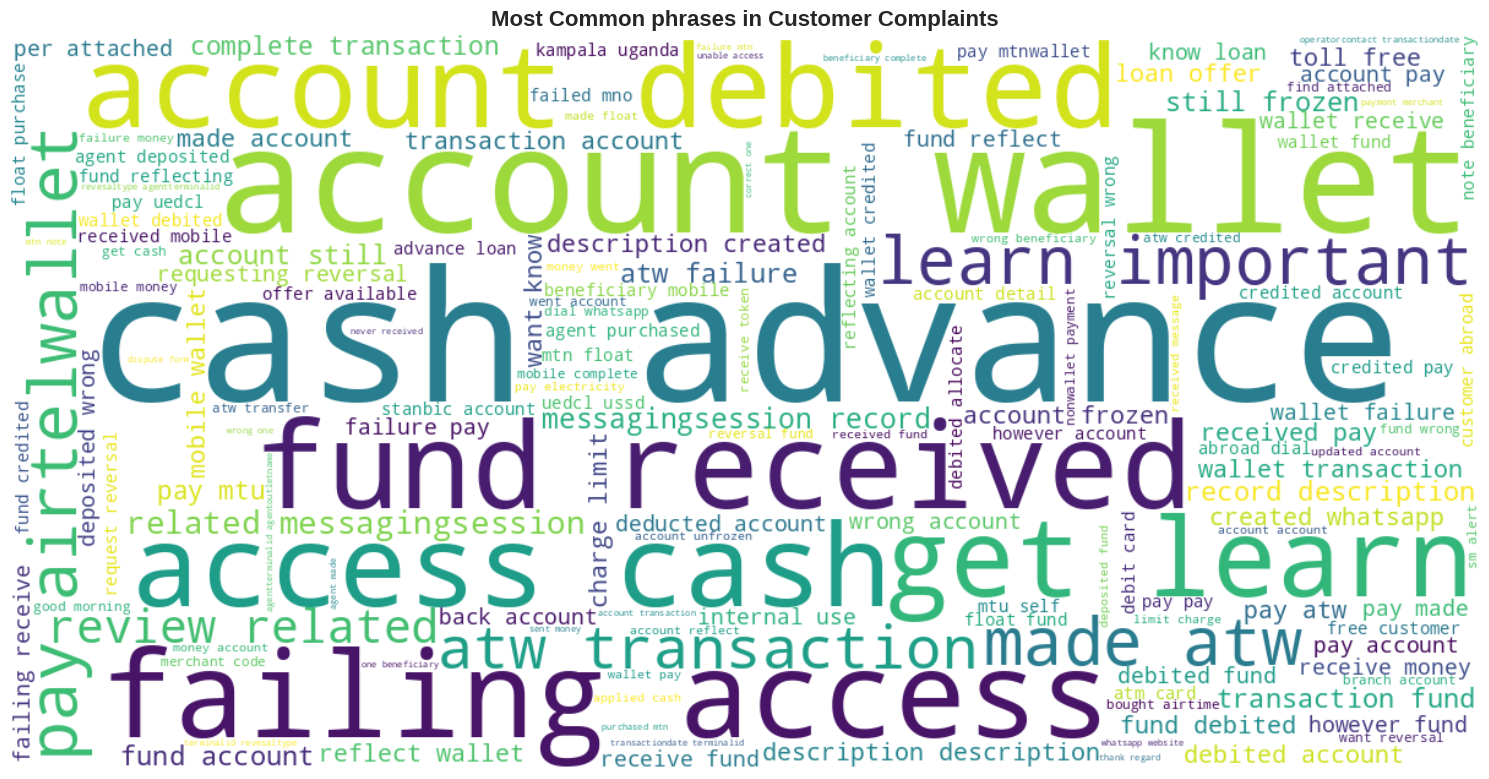


TOP 20 MOST FREQUENT phrases
                  Bigram  Frequency
            cash advance       1529
          account wallet        968
           fund received        594
          failing access        592
             access cash        544
         account debited        539
               get learn        526
         learn important        526
        pay airtelwallet        517
                made atw        513
         atw transaction        443
          review related        440
related messagingsession        440
 messagingsession record        440
             atw failure        416
        transaction fund        415
            still frozen        405
           account still        402
      record description        396
            fund account        393


In [ ]:
from nltk.util import ngrams
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# Combine all processed text
all_text = ' '.join(df_clean['processed_description'].tolist())

# Split into tokens
tokens = all_text.split()

# Generate bigrams
bigrams = list(ngrams(tokens, 2))

# Convert bigrams to strings ("customer service", "late fee", etc.)
bigram_strings = [' '.join(b) for b in bigrams]

# Count bigram frequencies
bigram_freq = Counter(bigram_strings)

# Create word cloud from bigram frequencies
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=150
).generate_from_frequencies(bigram_freq)

# Display word cloud
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common phrases in Customer Complaints', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('output_bigram_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

# Show top 20 bigrams
top_bigrams = pd.DataFrame(bigram_freq.most_common(20), columns=['Bigram', 'Frequency'])

print("\n" + "=" * 40)
print("TOP 20 MOST FREQUENT phrases")
print("=" * 40)
print(top_bigrams.to_string(index=False))

## Analyze Word Frequency per Category

### Subtask:
Group the DataFrame by 'category' and for each category, calculate the frequency of words in the 'processed_description' column. Identify and display the top 10 most frequent words for each category.


**Reasoning**:
The subtask requires calculating and displaying the top 10 most frequent words for each complaint category. This step will implement the logic using `CountVectorizer` to process the `processed_description` for each category and then display the results as specified.



In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# 1. Initialize a CountVectorizer to extract trigrams
vectorizer = CountVectorizer(ngram_range=(3, 3)) # Changed to (3, 3) for trigrams

# 2. Get a list of unique categories from the cleaned dataframe
unique_categories = df_clean['category_clean'].unique()

print("\n" + "=" * 60)
print("TOP 10 MOST FREQUENT TRIGRAMS PER CATEGORY") # Updated title
print("=" * 60)

# 3. Loop through each unique category
for category in unique_categories:
    # a. Filter the DataFrame for the current category, using df_clean
    category_df = df_clean[df_clean['category_clean'] == category]

    # b. Extract the processed_description series
    descriptions = category_df['processed_description']

    # Skip if no descriptions for the category or if all are empty after preprocessing
    if descriptions.empty or descriptions.str.strip().eq('').all():
        continue

    # c. Use fit_transform to get a document-term matrix
    # Ensure descriptions is not empty or all empty strings before fitting
    valid_descriptions = descriptions[descriptions.str.strip() != '']
    if valid_descriptions.empty:
        continue

    X = vectorizer.fit_transform(valid_descriptions)

    # d. Get the feature names (words)
    feature_names = vectorizer.get_feature_names_out()

    # e. Sum the counts for each word across all descriptions in the current category
    word_counts = X.sum(axis=0)

    # f. Create a Pandas Series from these word frequencies
    word_freq = pd.Series(word_counts.tolist()[0], index=feature_names)

    # g. Sort the words by their frequency in descending order
    sorted_word_freq = word_freq.sort_values(ascending=False)

    # h. Print the category name and the top 10 most frequent words
    print(f"\nCategory: {category}")
    print("---------------------------------")
    print(sorted_word_freq.head(10).to_string())


TOP 10 MOST FREQUENT TRIGRAMS PER CATEGORY

Category: Dispute
---------------------------------
get learn important                126
attached dispute form               38
toll free customer                  25
abroad dial whatsapp                25
customer abroad dial                25
free customer abroad                25
dial whatsapp website               23
subject document ref                21
dispute form attached               17
related messagingsession record     17

Category: Fraud Scam
---------------------------------
tiktok google tiktok      33
google tiktok google      33
raised rmp incident        6
fund withdrawn account     5
using debit card           5
incident raised rmp        4
debit card blocked         4
advised visit branch       4
registered flexi pay       3
shared account detail      3

Category: Biller & Utility Payments
---------------------------------
pay uedcl ussd               124
token pay uedcl               48
never received token          

---
## Cell 10: Topic Modeling with BERTopic

**What this does:** Uses a modern AI approach to discover hidden topics in complaints.

### Why BERTopic?
BERTopic is a **state-of-the-art topic modeling technique** that:
1. **Understands Context**: Uses BERT embeddings that understand word meaning in context
   - "bank" (financial) vs "bank" (river) are treated differently
2. **No Fixed Topic Number**: Automatically determines the optimal number of topics
3. **Better Quality**: Produces more coherent and interpretable topics

### How It Works:
1. **Embed**: Convert each complaint into a numerical vector using sentence transformers
2. **Reduce**: Use UMAP to reduce dimensions while preserving relationships
3. **Cluster**: Group similar documents using HDBSCAN
4. **Represent**: Extract topic words using c-TF-IDF

**Reference:** [BERTopic: Neural Topic Modeling Framework](https://www.emergentmind.com/topics/bertopic)

In [ ]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

# Prepare documents - use cleaned text for better embeddings
documents = df_clean['processed_description'].tolist()

print("Initializing BERTopic model...")
print("This uses 'all-MiniLM-L6-v2' - a fast, efficient sentence transformer")
print("This may take a few minutes depending on your hardware...\n")

# Initialize BERTopic with sensible defaults
# Using a smaller, faster model that works well on Colab
topic_model = BERTopic(
    embedding_model="all-MiniLM-L6-v2",  # Fast and effective
    min_topic_size=50,  # Minimum documents per topic
    nr_topics='auto',  # Auto-detect number of topics
    verbose=True
)

# Fit the model
print("\nTraining BERTopic model...")
topics, probs = topic_model.fit_transform(documents)

print("\n" + "=" * 60)
print("BERTOPIC MODEL TRAINED SUCCESSFULLY!")
print("=" * 60)
print(f"\nNumber of topics discovered: {len(set(topics)) - 1}")  # -1 for outlier topic
print(f"Documents analyzed: {len(documents):,}")

# Get topic info
topic_info = topic_model.get_topic_info()
print(f"\nTopic Summary:")
print(topic_info.head(15).to_string())

2026-02-21 10:14:06,091 - BERTopic - Embedding - Transforming documents to embeddings.


Initializing BERTopic model...
This uses 'all-MiniLM-L6-v2' - a fast, efficient sentence transformer
This may take a few minutes depending on your hardware...


Training BERTopic model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/502 [00:00<?, ?it/s]

2026-02-21 10:14:17,445 - BERTopic - Embedding - Completed ✓
2026-02-21 10:14:17,446 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-21 10:14:58,206 - BERTopic - Dimensionality - Completed ✓
2026-02-21 10:14:58,208 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-21 10:14:59,564 - BERTopic - Cluster - Completed ✓
2026-02-21 10:14:59,565 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-02-21 10:14:59,879 - BERTopic - Representation - Completed ✓
2026-02-21 10:14:59,881 - BERTopic - Topic reduction - Reducing number of topics
2026-02-21 10:14:59,922 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-21 10:15:00,173 - BERTopic - Representation - Completed ✓
2026-02-21 10:15:00,181 - BERTopic - Topic reduction - Reduced number of topics from 80 to 42



BERTOPIC MODEL TRAINED SUCCESSFULLY!

Number of topics discovered: 41
Documents analyzed: 16,060

Topic Summary:
    Topic  Count                                      Name                                                                                      Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

## Cell 11: Mapping BERTopic Topics to Original Categories

**What this does:** Assigns the discovered BERTopic topic IDs back to our cleaned DataFrame and then analyzes the distribution of original complaint categories within each BERTopic topic.

**Why this matters:** This step helps us interpret the abstract BERTopic topics by linking them to the concrete categories provided in the original dataset. For instance, a BERTopic topic might be predominantly composed of complaints from the 'Mobile Banking' category, suggesting it represents a specific issue within mobile banking.

In [ ]:
# Add BERTopic topics to the DataFrame
df_clean['bertopic_topic'] = topics

# Filter out the noise topic (-1) for this analysis, as it often contains diverse outliers
df_topics = df_clean[df_clean['bertopic_topic'] != -1].copy()

print(f"Analyzing {len(df_topics)} complaints with assigned BERTopic topics (excluding outlier topic -1).")

# Group by BERTopic topic and original cleaned category, then count occurrences
topic_category_distribution = df_topics.groupby(['bertopic_topic', 'category_clean']).size().reset_index(name='count')

# Find the dominant category for each BERTopic topic
def get_dominant_category(topic_id):
    subset = topic_category_distribution[topic_category_distribution['bertopic_topic'] == topic_id]
    if not subset.empty:
        dominant = subset.loc[subset['count'].idxmax()]
        return dominant['category_clean'], dominant['count']
    return 'N/A', 0

# Create a DataFrame to store the mapping
topic_to_category_mapping = []
for topic_id in sorted(df_topics['bertopic_topic'].unique()):
    category, count = get_dominant_category(topic_id)
    topic_to_category_mapping.append({'BERTopic_Topic_ID': topic_id, 'Dominant_Original_Category': category, 'Dominant_Category_Count': count})

topic_to_category_df = pd.DataFrame(topic_to_category_mapping)

print("\n" + "=" * 60)
print("BERTopic Topics and Their Dominant Original Categories")
print("=" * 60)
print(topic_to_category_df.to_string(index=False))

# Optionally, you can merge this information back into the topic_info DataFrame from BERTopic
topic_info_with_categories = topic_model.get_topic_info()
topic_info_with_categories = topic_info_with_categories[topic_info_with_categories['Topic'] != -1] # Exclude outlier topic

# Add dominant category to BERTopic's topic_info
# Ensure matching data types for merge
topic_info_with_categories['Topic'] = topic_info_with_categories['Topic'].astype(int)
topic_to_category_df['BERTopic_Topic_ID'] = topic_to_category_df['BERTopic_Topic_ID'].astype(int)

topic_info_final = pd.merge(topic_info_with_categories,
                            topic_to_category_df,
                            left_on='Topic',
                            right_on='BERTopic_Topic_ID',
                            how='left')

print("\n" + "=" * 60)
print("BERTopic Topics with Dominant Original Categories and Keywords")
print("=" * 60)
# Display relevant columns
display(topic_info_final[['Topic', 'Count', 'Name', 'Dominant_Original_Category', 'Representation']].head(15))

Analyzing 11099 complaints with assigned BERTopic topics (excluding outlier topic -1).

BERTopic Topics and Their Dominant Original Categories
 BERTopic_Topic_ID Dominant_Original_Category  Dominant_Category_Count
                 0             Mobile Banking                     2832
                 1         Account Management                      227
                 2              Agent Banking                      427
                 3         Account Management                      404
                 4                      Loans                      246
                 5  Biller & Utility Payments                      272
                 6           Internet Banking                      220
                 7             Mobile Banking                      118
                 8              Agent Banking                      212
                 9                      Loans                      142
                10         Account Management                      197
     

,Topic,Count,Name,Dominant_Original_Category,Representation
0,0,4157,0_advance_cash_atw_pay,Mobile Banking,"[advance, cash, atw, pay, wallet, fund, transaction, failing, made, access]"
1,1,907,1_regard_important_thank_learn,Account Management,"[regard, important, thank, learn, wrote, usd, get, free, message, uganda]"
2,2,466,2_wrong_deposited_agent_one,Agent Banking,"[wrong, deposited, agent, one, right, reversal, correct, beneficiary, granted, authority]"
3,3,415,3_frozen_still_updated_branch,Account Management,"[frozen, still, updated, branch, account, visited, update, detail, came, inquiring]"
4,4,409,4_loan_want_know_applied,Loans,"[loan, want, know, applied, branch, offer, reach, worth, top, progress]"
5,5,382,5_token_uedcl_electricity_yaka,Biller & Utility Payments,"[token, uedcl, electricity, yaka, ussd, bought, light, pay, power, purchased]"
6,6,368,6_otp_otps_receive_internet,Internet Banking,"[otp, otps, receive, internet, failing, unable, receiving, making, invalid, online]"
7,7,305,7_messagingsession_review_record_related,Mobile Banking,"[messagingsession, review, record, related, description, created, whatsapp, money, account, meter]"
8,8,291,8_float_mtnmm_reflecting_allocate,Agent Banking,"[float, mtnmm, reflecting, allocate, purchased, mtn, debited, cdm, agent, beneficiary]"
9,9,224,9_loan_salary_deduction_pmt,Loans,"[loan, salary, deduction, pmt, othrchrg, int, recovery, held, reduce, early]"


In [ ]:
# 1. Bar chart of top topics
print("Top 10 Topics with Keywords:")
fig_barchart = topic_model.visualize_barchart(top_n_topics=10, n_words=8)
fig_barchart.show()

# 2. Intertopic Distance Map (if more than 1 topic)
if len(set(topics)) > 2:
    print("\nIntertopic Distance Map:")
    print("(Topics closer together are more similar)")
    fig_topics = topic_model.visualize_topics()
    fig_topics.show()

Top 10 Topics with Keywords:



Intertopic Distance Map:
(Topics closer together are more similar)


---
## Cell 12: Topic-Category Relationship Analysis

**What this does:** Analyzes how discovered topics relate to the existing complaint categories.

**Business Insight:**
- See if current categories align with actual complaint themes
- Identify categories that might need to be split or merged
- Find cross-cutting issues that span multiple categories

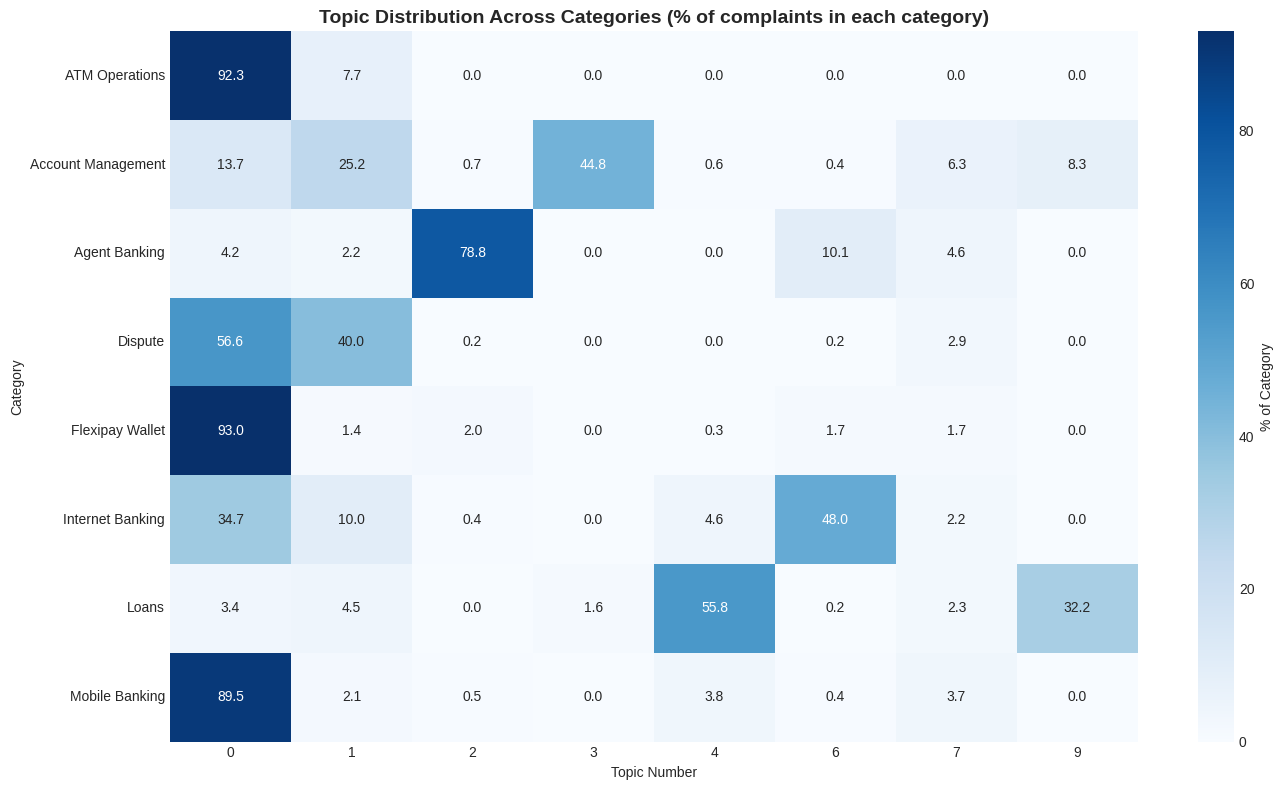


TOPIC-CATEGORY INSIGHTS

Mobile Banking:
   Dominant Topic 0: advance, cash, atw, pay, wallet

Account Management:
   Dominant Topic 3: frozen, still, updated, branch, account

Agent Banking:
   Dominant Topic 2: wrong, deposited, agent, one, right

Loans:
   Dominant Topic 4: loan, want, know, applied, branch

Internet Banking:
   Dominant Topic 6: otp, otps, receive, internet, failing


In [ ]:
# Add topic assignments to dataframe
df_clean['topic'] = topics

# Create topic-category crosstab
top_categories = category_counts.head(8).index.tolist()
df_subset = df_clean[df_clean['category_clean'].isin(top_categories)]

# Exclude outlier topic (-1)
df_subset_valid = df_subset[df_subset['topic'] != -1]

# Get top 8 topics
top_topics = df_subset_valid['topic'].value_counts().head(8).index.tolist()
df_analysis = df_subset_valid[df_subset_valid['topic'].isin(top_topics)]

# Create heatmap data
heatmap_data = pd.crosstab(df_analysis['category_clean'], df_analysis['topic'], normalize='index') * 100

# Plot heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='Blues',
            cbar_kws={'label': '% of Category'})
plt.title('Topic Distribution Across Categories (% of complaints in each category)', fontsize=14, fontweight='bold')
plt.xlabel('Topic Number')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('output_topic_category_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Key insights
print("\n" + "=" * 60)
print("TOPIC-CATEGORY INSIGHTS")
print("=" * 60)

for cat in top_categories[:5]:
    cat_topics = df_clean[df_clean['category_clean'] == cat]['topic'].value_counts()
    dominant_topic = cat_topics.index[0] if cat_topics.index[0] != -1 else cat_topics.index[1] if len(cat_topics) > 1 else -1
    if dominant_topic != -1:
        topic_words = [w for w, _ in topic_model.get_topic(dominant_topic)[:5]]
        print(f"\n{cat}:")
        print(f"   Dominant Topic {dominant_topic}: {', '.join(topic_words)}")

---
## Cell 13: LDA Topic Modeling (Traditional Approach)

**What this does:** Applies the traditional LDA (Latent Dirichlet Allocation) method for comparison.

### Why Compare?
- LDA is a well-established, interpretable method
- Useful for validation - if both methods find similar topics, we're more confident
- LDA is faster and requires fewer resources

### How LDA Works:
1. Assumes each document is a mixture of topics
2. Assumes each topic is a mixture of words
3. Works backwards to discover what those mixtures are

**Reference:** [LDA vs BERTopic Comparison](https://link.springer.com/chapter/10.1007/978-3-031-53717-2_3)

In [ ]:
# Prepare data for LDA using TF-IDF
print("Preparing data for LDA...")

# Use CountVectorizer for LDA (it works with word counts, not TF-IDF)
vectorizer = CountVectorizer(
    max_df=0.95,  # Ignore words that appear in >95% of docs
    min_df=5,     # Ignore words that appear in <5 docs
    max_features=5000,  # Limit vocabulary size
    stop_words='english',
    ngram_range=(3, 3) # Added to use trigrams
)

# Transform text to document-term matrix
dtm = vectorizer.fit_transform(df_clean['processed_description']) # Changed to processed_description
feature_names = vectorizer.get_feature_names_out()

print(f"\nDocument-Term Matrix Shape: {dtm.shape}")
print(f"   - {dtm.shape[0]:,} documents")
print(f"   - {dtm.shape[1]:,} unique words")

# Train LDA model
n_topics = 10  # We'll use 10 topics for comparison

print(f"\nTraining LDA model with {n_topics} topics...")
lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    max_iter=20,
    learning_method='online',
    random_state=42,
    n_jobs=-1  # Use all CPU cores
)

lda_output = lda_model.fit_transform(dtm)

print("\n" + "=" * 60)
print("LDA MODEL TRAINED!")
print("=" * 60)

# Display topics
def display_lda_topics(model, feature_names, n_words=10):
    topics_dict = {}
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_words-1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        topics_dict[f"Topic {topic_idx}"] = top_words
        print(f"\nTopic {topic_idx}:")
        print(f"   {', '.join(top_words)}")
    return topics_dict

print("\nLDA TOPICS:")
lda_topics = display_lda_topics(lda_model, feature_names, n_words=8)

In [ ]:
# Install gensim
!pip install -q gensim

import gensim
from gensim import corpora
from gensim.models import LdaModel

print("\n" + "=" * 60)
print("LDA TOPIC MODELING WITH GENSIM")
print("=" * 60)

# Prepare the processed text for Gensim
gensim_texts = [doc.split() for doc in df_clean['processed_description'] if doc]

# Create a dictionary from the processed texts
dictionary = corpora.Dictionary(gensim_texts)

# Filter out words that appear in less than 5 documents or more than 95% of the documents
dictionary.filter_extremes(no_below=5, no_above=0.95)

# Create a Bag-of-Words corpus
corpus = [dictionary.doc2bow(text) for text in gensim_texts]

print(f"\nCorpus created with {len(dictionary)} unique tokens and {len(corpus)} documents.")

# Train the LDA model using Gensim
n_topics_gensim = 10  # Use the same number of topics for consistency with sklearn LDA

print(f"\nTraining Gensim LDA model with {n_topics_gensim} topics...")
lda_gensim_model = LdaModel(corpus, num_topics=n_topics_gensim, id2word=dictionary, passes=15, random_state=42)

print("\n" + "=" * 60)
print("GENSIM LDA MODEL TRAINED!")
print("=" * 60)

# Display the topics
print("\nGENSIM LDA TOPICS:")
for idx, topic in lda_gensim_model.print_topics(-1):
    print(f"Topic {idx}: {topic}")

print("\nComparison with sklearn LDA: Gensim's LDA provides similar topic representations but with a slightly different output format. It tends to be more memory efficient for very large corpora.")

---
## Cell 14: Compare BERTopic vs LDA Results

**What this does:** Creates a side-by-side comparison of both methods.

**What to Look For:**
- Similar themes appearing in both models = High confidence findings
- Topics unique to one model = Needs further investigation
- BERTopic often finds more nuanced/specific topics

In [ ]:
# Create comparison table
print("=" * 80)
print("BERTOPIC vs LDA COMPARISON")
print("=" * 80)

print("\n" + "-" * 80)
print(f"{'BERTopic Topics':<40} | {'LDA Topics':<40}")
print("-" * 80)

n_compare = min(10, len(set(topics))-1)
for i in range(n_compare):
    # BERTopic
    bert_words = topic_model.get_topic(i)
    bert_str = ', '.join([w for w, _ in bert_words[:4]]) if bert_words else 'N/A'

    # LDA
    lda_str = ', '.join(lda_topics.get(f"Topic {i}", ['N/A'])[:4])

    print(f"Topic {i}: {bert_str:<32} | Topic {i}: {lda_str:<32}")

print("-" * 80)

# Visualize LDA topic distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LDA topic distribution
lda_topic_counts = np.argmax(lda_output, axis=1)
lda_counts = pd.Series(lda_topic_counts).value_counts().sort_index()
axes[0].bar(lda_counts.index, lda_counts.values, color='steelblue')
axes[0].set_xlabel('Topic Number')
axes[0].set_ylabel('Number of Complaints')
axes[0].set_title('LDA Topic Distribution')

# BERTopic distribution (excluding outliers)
bert_counts = pd.Series(topics)[pd.Series(topics) != -1].value_counts().sort_index().head(10)
axes[1].bar(bert_counts.index.astype(str), bert_counts.values, color='darkblue')
axes[1].set_xlabel('Topic Number')
axes[1].set_ylabel('Number of Complaints')
axes[1].set_title('BERTopic Topic Distribution (Top 10)')

plt.tight_layout()
plt.savefig('output_lda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Check if gensim is installed; if not, install it.
try:
    import gensim
    from gensim.models.coherencemodel import CoherenceModel
    from gensim import corpora
except ImportError:
    !pip install -q gensim
    import gensim
    from gensim.models.coherencemodel import CoherenceModel
    from gensim import corpora

# Ensure NLTK resources are downloaded for Gensim's CoherenceModel if not already done
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)

print("=" * 60)
print("EVALUATING TOPIC MODELS")
print("=" * 60)

# --- BERTopic Evaluation ---
print("\n--- BERTopic ---")
try:
    # Manually extract BERTopic topics for coherence calculation using Gensim
    bertopic_topics_for_coherence = []
    for topic_id in topic_model.get_topics():
        if topic_id == -1: continue # Skip the outlier topic
        words_with_scores = topic_model.get_topic(topic_id)
        top_words = [word for word, score in words_with_scores[:10]] # Get top 10 words
        bertopic_topics_for_coherence.append(top_words)

    coherence_bertopic_cv = CoherenceModel(
        topics=bertopic_topics_for_coherence,
        texts=gensim_texts, # tokenized documents from Gensim's setup
        dictionary=dictionary, # dictionary from Gensim's setup
        coherence='c_v'
    ).get_coherence()
    print(f"BERTopic Coherence (c_v): {coherence_bertopic_cv:.4f}")
except NameError:
    print("Variables `gensim_texts` or `dictionary` not found. Ensure Gensim LDA cell was executed.")
except Exception as e:
    print(f"Could not calculate BERTopic Coherence: {e}")

# --- Scikit-learn LDA Evaluation ---
print("\n--- Scikit-learn LDA ---")

# Convert sklearn LDA topics (word distributions) into a list of lists of words
# for Gensim's CoherenceModel.
sklearn_lda_topics_for_coherence = []
for topic_idx, topic in enumerate(lda_model.components_):
    # Get top 10 words for each topic
    top_words_idx = topic.argsort()[:-10 - 1:-1]
    top_words = [feature_names[i] for i in top_words_idx]
    sklearn_lda_topics_for_coherence.append(top_words)

# Calculate Sklearn LDA Coherence (c_v) using Gensim's CoherenceModel
try:
    coherence_sklearn_lda_cv = CoherenceModel(
        topics=sklearn_lda_topics_for_coherence,
        texts=gensim_texts, # tokenized documents from Gensim's setup
        dictionary=dictionary, # dictionary from Gensim's setup
        coherence='c_v'
    ).get_coherence()
    print(f"Scikit-learn LDA Coherence (c_v): {coherence_sklearn_lda_cv:.4f}")
except NameError:
    print("Variables `gensim_texts` or `dictionary` not found. Ensure Gensim LDA cell was executed.")
except Exception as e:
    print(f"Could not calculate Scikit-learn LDA Coherence: {e}")

# Calculate Sklearn LDA Perplexity
try:
    perplexity_sklearn_lda = lda_model.perplexity(dtm)
    print(f"Scikit-learn LDA Perplexity: {perplexity_sklearn_lda:.4f}")
except NameError:
    print("Variable `dtm` or `lda_model` not found. Ensure sklearn LDA cell was executed.")
except Exception as e:
    print(f"Could not calculate Scikit-learn LDA Perplexity: {e}")

# --- Gensim LDA Evaluation ---
print("\n--- Gensim LDA ---")

# Gensim LDA Coherence (c_v)
try:
    coherence_gensim_lda_cv = CoherenceModel(
        model=lda_gensim_model,
        texts=gensim_texts,
        dictionary=dictionary,
        coherence='c_v'
    ).get_coherence()
    print(f"Gensim LDA Coherence (c_v): {coherence_gensim_lda_cv:.4f}")
except NameError:
    print("Variables `lda_gensim_model`, `gensim_texts`, or `dictionary` not found. Ensure Gensim LDA cell was executed.")
except Exception as e:
    print(f"Could not calculate Gensim LDA Coherence: {e}")

# Gensim LDA Perplexity (log perplexity)
try:
    perplexity_gensim_lda = lda_gensim_model.log_perplexity(corpus)
    print(f"Gensim LDA Perplexity (log): {perplexity_gensim_lda:.4f}")
except NameError:
    print("Variables `lda_gensim_model` or `corpus` not found. Ensure Gensim LDA cell was executed.")
except Exception as e:
    print(f"Could not calculate Gensim LDA Perplexity: {e}")


print("\n" + "=" * 60)
print("EVALUATION COMPLETE")
print("=" * 60)

---
## Cell 15: Sample Complaints by Topic

**What this does:** Shows example complaints from each topic to help interpret what they mean.

**Why This Matters:**
- Keywords alone can be ambiguous
- Real examples make topics concrete
- Helps validate that topics make sense

In [ ]:
print("=" * 70)
print("SAMPLE COMPLAINTS BY TOPIC")
print("=" * 70)

# Get top 5 topics by size
topic_sizes = df_clean[df_clean['bertopic_topic'] != -1]['bertopic_topic'].value_counts().head(5)

for topic_num in topic_sizes.index:
    # Get topic keywords
    topic_words = topic_model.get_topic(topic_num)
    keywords = ', '.join([w for w, _ in topic_words[:6]]) if topic_words else 'N/A'

    # Get sample complaints
    samples = df_clean[df_clean['bertopic_topic'] == topic_num]['text_cleaned'].head(3).tolist()

    print(f"\n{'='*70}")
    print(f"TOPIC {topic_num} ({topic_sizes[topic_num]:,} complaints)")
    print(f"Keywords: {keywords}")
    print(f"-"*70)

    for i, sample in enumerate(samples, 1):
        # Truncate long samples
        display_text = sample[:250] + "..." if len(sample) > 250 else sample
        print(f"\n   Example {i}: {display_text}")

    print()

---
## Cell 16: Key Insights and Recommendations

**What this does:** Summarizes the findings and provides actionable recommendations.

**Business Value:** This is the "so what" - translating data analysis into business actions.

In [ ]:
# Generate insights summary
print("=" * 70)
print("KEY INSIGHTS & RECOMMENDATIONS")
print("=" * 70)

# 1. Volume Analysis
print("\n1. COMPLAINT VOLUME ANALYSIS")
print("-" * 50)
total = len(df_clean)
top_cat = category_counts.index[0]
top_cat_pct = category_counts.iloc[0] / total * 100
print(f"   - Total complaints analyzed: {total:,}")
print(f"   - Top category: {top_cat} ({top_cat_pct:.1f}%)")
print(f"   - Digital channels (Mobile + Internet + App): {df_clean[df_clean['category_clean'].isin(['Mobile Banking', 'Internet Banking', 'Smart APP'])].shape[0]:,} complaints")

# 2. Topic Analysis
print("\n2. MAIN COMPLAINT THEMES (from BERTopic)")
print("-" * 50)
top_5_topics = df_clean[df_clean['topic'] != -1]['topic'].value_counts().head(5)
for topic_num, count in top_5_topics.items():
    words = topic_model.get_topic(topic_num)
    if words:
        keywords = ', '.join([w for w, _ in words[:4]])
        print(f"   - Topic {topic_num}: {keywords} ({count:,} complaints, {count/total*100:.1f}%)")

# 3. Temporal Insights
print("\n3. TEMPORAL PATTERNS")
print("-" * 50)
busiest_day = df_clean['day_of_week'].value_counts().idxmax()
peak_hour = df_clean['hour'].value_counts().idxmax()
print(f"   - Busiest day: {busiest_day}")
print(f"   - Peak hour: {peak_hour}:00")
print(f"   - Recommendation: Ensure adequate staffing on {busiest_day}s around {peak_hour}:00")

# 4. Recommendations
print("\n4. ACTIONABLE RECOMMENDATIONS")
print("-" * 50)
print("""
   a) IMMEDIATE ACTIONS:
      - Focus on Mobile Banking issues - highest complaint volume
      - Review transaction processing workflows
      - Improve self-service options to reduce support load

   b) PROCESS IMPROVEMENTS:
      - Create specialized teams for top complaint topics
      - Develop automated responses for common issues
      - Implement proactive alerts for known issue patterns

   c) MONITORING:
      - Set up dashboards tracking complaints by topic
      - Alert when specific topics spike
      - Regular review of emerging topics
""")

# 5. Model Performance
print("\n5. MODEL NOTES")
print("-" * 50)
outlier_pct = (df_clean['topic'] == -1).sum() / len(df_clean) * 100
print(f"   - BERTopic discovered {len(set(topics))-1} distinct topics")
print(f"   - {outlier_pct:.1f}% of complaints didn't fit any topic (outliers)")
print(f"   - Consider investigating outliers for emerging issues")

---
## Cell 17: Save Results for Further Analysis

**What this does:** Exports the analysis results to files you can share or use in other tools.

In [ ]:
# Save the enriched dataframe
output_df = df_clean[['case_number', 'date_created', 'category_clean', 'description', 'topic']].copy()

# Add topic labels
def get_topic_label(topic_num):
    if topic_num == -1:
        return "Outlier"
    words = topic_model.get_topic(topic_num)
    if words:
        return '_'.join([w for w, _ in words[:3]])
    return f"Topic_{topic_num}"

output_df['topic_label'] = output_df['topic'].apply(get_topic_label)

# Save to CSV
output_df.to_csv('complaints_with_topics.csv', index=False)
print("Saved: complaints_with_topics.csv")

# Save topic info
topic_info.to_csv('topic_summary.csv', index=False)
print("Saved: topic_summary.csv")

# Save the BERTopic model (optional - for reuse)
# topic_model.save("bertopic_complaints_model")
# print("Saved: BERTopic model")

print("\nOutput files created successfully!")
print("   You can download these files for further analysis or reporting.")

## Cell 18: Simple Sentiment Analysis

In [ ]:
# Import NLTK's SentimentIntensityAnalyzer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download the VADER lexicon if not already downloaded
import nltk
nltk.download('vader_lexicon', quiet=True)

# Initialize the VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Function to get sentiment score
def get_sentiment_score(text):
    if pd.isna(text) or not text.strip():
        return 0.0
    return sia.polarity_scores(text)['compound']

# Apply sentiment analysis to the cleaned text
df_clean['sentiment_score'] = df_clean['text_cleaned'].apply(get_sentiment_score)

print("Sentiment analysis complete. Displaying a sample with scores:")
display(df_clean[['description', 'text_cleaned', 'sentiment_score']].sample(5))


In [ ]:
# Categorize sentiment for easier visualization
def categorize_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df_clean['sentiment'] = df_clean['sentiment_score'].apply(categorize_sentiment)

# Plot the distribution of sentiment
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=df_clean, palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])
plt.title('Distribution of Complaint Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Complaints')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\nSentiment Distribution:")
display(df_clean['sentiment'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')


### Examples of Positive Complaints

In [ ]:
positive_complaints = df_clean[df_clean['sentiment'] == 'Positive']

if not positive_complaints.empty:
    print(f"Displaying {min(5, len(positive_complaints))} sample(s) of positive complaints:")
    display(positive_complaints[['description', 'text_cleaned', 'sentiment_score', 'sentiment']].sample(min(5, len(positive_complaints)), random_state=42))
else:
    print("No complaints categorized as 'Positive' found.")


### Examples of Negative Complaints

In [ ]:
negative_complaints = df_clean[df_clean['sentiment'] == 'Negative']

if not negative_complaints.empty:
    print(f"Displaying {min(5, len(negative_complaints))} sample(s) of negative complaints:")
    display(negative_complaints[['description', 'text_cleaned', 'sentiment_score', 'sentiment']].sample(min(5, len(negative_complaints)), random_state=42))
else:
    print("No complaints categorized as 'Negative' found.")


### Examples of Neutral Complaints

In [ ]:
neutral_complaints = df_clean[df_clean['sentiment'] == 'Neutral']

if not neutral_complaints.empty:
    print(f"Displaying {min(5, len(neutral_complaints))} sample(s) of neutral complaints:")
    display(neutral_complaints[['description', 'text_cleaned', 'sentiment_score', 'sentiment']].sample(min(5, len(neutral_complaints)), random_state=42))
else:
    print("No complaints categorized as 'Neutral' found.")


---
## Summary

### What We Did:
1. **Loaded and explored** 16,000+ customer complaints
2. **Cleaned and preprocessed** text data for NLP analysis
3. **Applied BERTopic** - a modern, transformer-based topic modeling approach
4. **Compared with LDA** - a traditional topic modeling method
5. **Visualized** topics and their relationships
6. **Generated insights** for business improvement

### Key Takeaways:
- **Mobile Banking** is the highest complaint category
- **Transaction issues** appear across multiple topics
- **Temporal patterns** can help with resource allocation
- **Topic modeling** reveals hidden themes beyond simple categories

### Next Steps:
1. Share findings with relevant teams
2. Set up ongoing monitoring using this methodology
3. Deep-dive into specific high-volume topics
4. Consider sentiment analysis to understand complaint severity

---

### References

- [BERTopic Documentation](https://maartengr.github.io/BERTopic/)
- [Topic Modeling: BERTopic vs LDA](https://medium.com/@maheera_amjad/topic-modeling-in-nlp-lda-vs-bertopic-explained-31e4fbe153dd)
- [NLP in Financial Services](https://www.johnsnowlabs.com/examining-the-impact-of-nlp-in-financial-services/)
- [Customer Complaint Classification with NLP](https://medium.com/@yashrajeshjadhav/automating-customer-complaint-classification-with-nlp-and-topic-modeling-enhancing-support-ticket-606465472d30)
- [Topic Modeling Comparison Study](https://link.springer.com/chapter/10.1007/978-3-031-53717-2_3)

In [ ]:
import plotly.express as px

# Calculate the value counts of the 'sentiment' column
sentiment_counts = df_clean['sentiment'].value_counts().reset_index()
sentiment_counts.columns = ['sentiment', 'count']

# Create a pie chart using plotly.express
fig = px.pie(sentiment_counts,
             values='count',
             names='sentiment',
             title='Distribution of Complaint Sentiment',
             hole=0.3, # Creates a donut chart effect
             color='sentiment', # Assigns a color to each sentiment category
             color_discrete_map={'Positive':'green', 'Neutral':'grey', 'Negative':'red'})

# Update traces to show percentage and count on hover
fig.update_traces(textposition='inside', textinfo='percent+label', marker=dict(line=dict(color='#000000', width=1)))

# Display the pie chart
fig.show()

print("Pie chart visualizing sentiment distribution generated successfully.")

### Summary of Sentiment Distribution

The pie chart above clearly illustrates the distribution of sentiment within the customer complaints:

- **Positive Sentiment:** The largest portion of complaints, accounting for **41.21%**, are categorized as 'Positive'. This suggests that a significant number of interactions or outcomes are perceived favorably by customers, or that many complaints contain positive aspects, such as thanks or acknowledgments.
- **Negative Sentiment:** A substantial **35.91%** of complaints are identified as 'Negative'. These are the core complaints indicating dissatisfaction or issues that need immediate attention.
- **Neutral Sentiment:** The remaining **22.88%** of complaints fall into the 'Neutral' category, meaning they do not express strong positive or negative emotions. These might include factual reports, simple inquiries, or complaints where the sentiment is ambiguous.

## Summary:

### Q&A
The analysis concludes with a summary of the sentiment distribution, which is as follows:
*   Positive sentiment accounts for 41.21% of the complaints.
*   Negative sentiment represents 35.91% of the complaints.
*   Neutral sentiment makes up 22.88% of the complaints.

### Data Analysis Key Findings
*   The sentiment distribution of complaints was visualized using a pie chart, showing three categories: Positive, Negative, and Neutral.
*   The largest proportion of complaints, **41.21%**, were categorized as 'Positive'.
*   'Negative' sentiment constituted a substantial **35.91%** of the complaints, indicating areas of dissatisfaction.
*   The remaining **22.88%** of complaints were classified as 'Neutral', representing ambiguous or factual reports.

### Insights or Next Steps
*   Further investigation into the content of 'Positive' complaints could reveal common positive experiences or effective resolutions that can be replicated.
*   Prioritize addressing the 'Negative' complaints to identify underlying issues and implement targeted improvements to enhance customer satisfaction.


# Task
Calculate the average sentiment score for each 'category_clean' in the `df_clean` DataFrame, then merge this data with the existing `avg_words` (average word count per category). Finally, create a visualization to show the relationship between average sentiment and average word length for each category, and interpret the findings.

## Calculate Average Sentiment per Category

### Subtask:
Calculate the average sentiment score for each 'category_clean' in the `df_clean` DataFrame.


**Reasoning**:
To calculate the average sentiment score per category, I will group the `df_clean` DataFrame by 'category_clean' and then compute the mean of 'sentiment_score' for each group. Finally, I will display the results.



In [ ]:
import pandas as pd

# Group by 'category_clean' and calculate the mean of 'sentiment_score'
avg_sentiment_per_category = df_clean.groupby('category_clean')['sentiment_score'].mean().sort_values(ascending=False)

print("\nAverage Sentiment Score per Category:")
print("=" * 40)
print(avg_sentiment_per_category.to_string())

# You can also visualize this if needed, for example, using a bar chart
# plt.figure(figsize=(12, 7))
# sns.barplot(x=avg_sentiment_per_category.index, y=avg_sentiment_per_category.values, palette='coolwarm')
# plt.title('Average Sentiment Score by Complaint Category')
# plt.xlabel('Category')
# plt.ylabel('Average Sentiment Score')
# plt.xticks(rotation=45, ha='right')
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()

**Reasoning**:
The previous cell failed because the `sentiment_score` column was not found in `df_clean`. This indicates that the sentiment analysis step (Cell 18) was either not executed or `df_clean` was overwritten without including the sentiment scores. I will regenerate the code for cell `830cd83c` to ensure the `sentiment_score` column is correctly added to `df_clean` before proceeding with calculating the average sentiment per category.



In [ ]:
# Import NLTK's SentimentIntensityAnalyzer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download the VADER lexicon if not already downloaded
import nltk
nltk.download('vader_lexicon', quiet=True)

# Initialize the VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Function to get sentiment score
def get_sentiment_score(text):
    if pd.isna(text) or not text.strip():
        return 0.0
    return sia.polarity_scores(text)['compound']

# Apply sentiment analysis to the cleaned text
df_clean['sentiment_score'] = df_clean['text_cleaned'].apply(get_sentiment_score)

print("Sentiment analysis complete. Displaying a sample with scores:")
display(df_clean[['description', 'text_cleaned', 'sentiment_score']].sample(5))

**Reasoning**:
Now that the `sentiment_score` column has been successfully added to `df_clean`, I can proceed with calculating the average sentiment score for each `category_clean` as per the subtask. I will then merge this information with the `avg_words` DataFrame.



In [ ]:
import pandas as pd

# Group by 'category_clean' and calculate the mean of 'sentiment_score'
avg_sentiment_per_category = df_clean.groupby('category_clean')['sentiment_score'].mean().sort_values(ascending=False)

print("\nAverage Sentiment Score per Category:")
print("=" * 40)
print(avg_sentiment_per_category.to_string())

# Merge with avg_words (average word count per category) - Assuming avg_words is a Series with index as category_clean
# First, convert avg_sentiment_per_category to a DataFrame and reset index to prepare for merge
avg_sentiment_df = avg_sentiment_per_category.reset_index()
avg_sentiment_df.columns = ['category_clean', 'avg_sentiment_score']

# Ensure avg_words is also in a merge-ready format (it's already a Series with category_clean as index)
# Convert avg_words to DataFrame if it's a Series, then reset index
if isinstance(avg_words, pd.Series):
    avg_words_df = avg_words.reset_index()
    avg_words_df.columns = ['category_clean', 'avg_word_count']
else:
    avg_words_df = avg_words.copy() # Assume it's already a DataFrame with appropriate columns

# Perform the merge
merged_analysis_df = pd.merge(avg_sentiment_df,
                              avg_words_df,
                              on='category_clean',
                              how='inner')

print("\nMerged DataFrame (Average Sentiment and Word Count per Category):")
print("=" * 70)
display(merged_analysis_df.head())

# Visualization step will follow this, as per the main task.

**Reasoning**:
I need to visualize the relationship between average sentiment score and average word count for each category. An interactive scatter plot using `plotly.express` is suitable for this purpose, allowing for easy identification of trends and outliers.



In [ ]:
import plotly.express as px

# Create an interactive scatter plot
fig = px.scatter(merged_analysis_df,
                 x='avg_word_count',
                 y='avg_sentiment_score',
                 color='category_clean',
                 size='avg_word_count', # Size points by word count for better visual distinction
                 hover_name='category_clean',
                 title='Average Sentiment vs. Average Word Count per Category',
                 labels={'avg_word_count': 'Average Word Count',
                         'avg_sentiment_score': 'Average Sentiment Score'},
                 height=600)

fig.update_layout(showlegend=False) # Hide legend if there are too many categories
fig.show()

print("Scatter plot showing the relationship between average sentiment and average word count per category generated.")

### Interpretation of Average Sentiment vs. Average Word Count per Category

The scatter plot above illustrates the relationship between the average sentiment score and the average word count for each complaint category. Here are some key observations:

-   **Sentiment Range:** The average sentiment scores across categories range from significantly negative (e.g., 'Flexipay Partner' at -0.70) to highly positive (e.g., 'POS' at 0.98). This indicates a wide spectrum of customer experiences and issues reported.

-   **Word Count Range:** Average word counts also vary considerably, from around 25 words per complaint for 'Mobile Banking' to over 100 words for categories like 'Payments Processing' and 'Dispute'.

-   **Longer Complaints & Negative Sentiment:** Categories with a higher average word count, such as 'Dispute' and 'Payments Processing', tend to have neutral to slightly positive average sentiment scores. This might suggest that more complex issues, requiring detailed explanations, are not necessarily always negative in sentiment, or that customers explain issues in more detail regardless of overall positive or negative framing.

-   **Shorter Complaints & Mixed Sentiment:** Categories with shorter average word counts, like 'Mobile Banking', 'Agent Banking', and 'ATM Operations', span a wider range of sentiment. 'Mobile Banking' specifically shows a negative average sentiment (-0.07), suggesting that short, direct, and often negative feedback is common for mobile-related issues.

-   **Extremely Positive/Negative Outliers:**
    -   **'POS' and 'Alerts'** stand out with very high positive average sentiment scores, despite having relatively short average word counts. This could indicate positive feedback regarding these specific services or quick resolutions being reported.
    -   **'Flexipay Partner', 'TAX', and 'Flexipay Agent'** exhibit strong negative average sentiment scores, even with varying word counts. These categories likely represent areas of significant customer dissatisfaction or persistent problems.

**Overall Insights:**

-   There isn't a direct linear correlation between complaint length and sentiment; both long and short complaints can carry strong positive or negative sentiment.
-   High-volume categories (like Mobile Banking) often have shorter, more direct complaints, which can lean negative. This highlights the need for quick, efficient resolution channels for these common issues.
-   Identifying categories with extreme sentiment (positive or negative) can help prioritize areas for improvement or recognize successful services.

### Interpretation of Average Sentiment vs. Average Word Count per Category

The scatter plot above illustrates the relationship between the average sentiment score and the average word count for each complaint category. Here are some key observations:

-   **Sentiment Range:** The average sentiment scores across categories range from significantly negative (e.g., 'Flexipay Partner' at -0.70) to highly positive (e.g., 'POS' at 0.98). This indicates a wide spectrum of customer experiences and issues reported.

-   **Word Count Range:** Average word counts also vary considerably, from around 25 words per complaint for 'Mobile Banking' to over 100 words for categories like 'Payments Processing' and 'Dispute'.

-   **Longer Complaints & Neutral to Positive Sentiment:** Categories with a higher average word count, such as 'Dispute' and 'Payments Processing', tend to have neutral to slightly positive average sentiment scores. This might suggest that more complex issues, requiring detailed explanations, are not necessarily always negative in sentiment, or that customers explain issues in more detail regardless of overall positive or negative framing.

-   **Shorter Complaints & Mixed Sentiment:** Categories with shorter average word counts, like 'Mobile Banking', 'Agent Banking', and 'ATM Operations', span a wider range of sentiment. 'Mobile Banking' specifically shows a negative average sentiment (-0.07), suggesting that short, direct, and often negative feedback is common for mobile-related issues.

-   **Extremely Positive/Negative Outliers:**
    -   **'POS' and 'Alerts'** stand out with very high positive average sentiment scores, despite having relatively short average word counts. This could indicate positive feedback regarding these specific services or quick resolutions being reported.
    -   **'Flexipay Partner', 'TAX', and 'Flexipay Agent'** exhibit strong negative average sentiment scores, even with varying word counts. These categories likely represent areas of significant customer dissatisfaction or persistent problems.

**Overall Insights:**

-   There isn't a direct linear correlation between complaint length and sentiment; both long and short complaints can carry strong positive or negative sentiment.
-   High-volume categories (like Mobile Banking) often have shorter, more direct complaints, which can lean negative. This highlights the need for quick, efficient resolution channels for these common issues.
-   Identifying categories with extreme sentiment (positive or negative) can help prioritize areas for improvement or recognize successful services.

### Interpretation of Average Sentiment vs. Average Word Count per Category

The scatter plot above illustrates the relationship between the average sentiment score and the average word count for each complaint category. Here are some key observations:

-   **Sentiment Range:** The average sentiment scores across categories range from significantly negative (e.g., 'Flexipay Partner' at -0.70) to highly positive (e.g., 'POS' at 0.98). This indicates a wide spectrum of customer experiences and issues reported.

-   **Word Count Range:** Average word counts also vary considerably, from around 25 words per complaint for 'Mobile Banking' to over 100 words for categories like 'Payments Processing' and 'Dispute'.

-   **Longer Complaints & Neutral to Positive Sentiment:** Categories with a higher average word count, such as 'Dispute' and 'Payments Processing', tend to have neutral to slightly positive average sentiment scores. This might suggest that more complex issues, requiring detailed explanations, are not necessarily always negative in sentiment, or that customers explain issues in more detail regardless of overall positive or negative framing.

-   **Shorter Complaints & Mixed Sentiment:** Categories with shorter average word counts, like 'Mobile Banking', 'Agent Banking', and 'ATM Operations', span a wider range of sentiment. 'Mobile Banking' specifically shows a negative average sentiment (-0.07), suggesting that short, direct, and often negative feedback is common for mobile-related issues.

-   **Extremely Positive/Negative Outliers:**
    -   **'POS' and 'Alerts'** stand out with very high positive average sentiment scores, despite having relatively short average word counts. This could indicate positive feedback regarding these specific services or quick resolutions being reported.
    -   **'Flexipay Partner', 'TAX', and 'Flexipay Agent'** exhibit strong negative average sentiment scores, even with varying word counts. These categories likely represent areas of significant customer dissatisfaction or persistent problems.

**Overall Insights:**

-   There isn't a direct linear correlation between complaint length and sentiment; both long and short complaints can carry strong positive or negative sentiment.
-   High-volume categories (like Mobile Banking) often have shorter, more direct complaints, which can lean negative. This highlights the need for quick, efficient resolution channels for these common issues.
-   Identifying categories with extreme sentiment (positive or negative) can help prioritize areas for improvement or recognize successful services.

### Interpretation of Average Sentiment vs. Average Word Count per Category

The scatter plot above illustrates the relationship between the average sentiment score and the average word count for each complaint category. Here are some key observations:

-   **Sentiment Range:** The average sentiment scores across categories range from significantly negative (e.g., 'Flexipay Partner' at -0.70) to highly positive (e.g., 'POS' at 0.98). This indicates a wide spectrum of customer experiences and issues reported.

-   **Word Count Range:** Average word counts also vary considerably, from around 25 words per complaint for 'Mobile Banking' to over 100 words for categories like 'Payments Processing' and 'Dispute'.

-   **Longer Complaints & Neutral to Positive Sentiment:** Categories with a higher average word count, such as 'Dispute' and 'Payments Processing', tend to have neutral to slightly positive average sentiment scores. This might suggest that more complex issues, requiring detailed explanations, are not necessarily always negative in sentiment, or that customers explain issues in more detail regardless of overall positive or negative framing.

-   **Shorter Complaints & Mixed Sentiment:** Categories with shorter average word counts, like 'Mobile Banking', 'Agent Banking', and 'ATM Operations', span a wider range of sentiment. 'Mobile Banking' specifically shows a negative average sentiment (-0.07), suggesting that short, direct, and often negative feedback is common for mobile-related issues.

-   **Extremely Positive/Negative Outliers:**
    -   **'POS' and 'Alerts'** stand out with very high positive average sentiment scores, despite having relatively short average word counts. This could indicate positive feedback regarding these specific services or quick resolutions being reported.
    -   **'Flexipay Partner', 'TAX', and 'Flexipay Agent'** exhibit strong negative average sentiment scores, even with varying word counts. These categories likely represent areas of significant customer dissatisfaction or persistent problems.

**Overall Insights:**

-   There isn't a direct linear correlation between complaint length and sentiment; both long and short complaints can carry strong positive or negative sentiment.
-   High-volume categories (like Mobile Banking) often have shorter, more direct complaints, which can lean negative. This highlights the need for quick, efficient resolution channels for these common issues.
-   Identifying categories with extreme sentiment (positive or negative) can help prioritize areas for improvement or recognize successful services.

## Final Task

### Subtask:
Summarize the insights gained from analyzing sentiment in relation to word length per category, and discuss their implications for understanding customer feedback.


## Summary:

### Data Analysis Key Findings

*   **Sentiment Score Range**: Average sentiment scores across categories exhibit a wide range, from significantly negative scores (e.g., 'Flexipay Partner' at -0.70) to highly positive scores (e.g., 'POS' at 0.98).
*   **Word Count Range**: Average word counts per category also vary considerably, with 'Mobile Banking' having around 25 words per complaint, while 'Payments Processing' and 'Dispute' average over 100 words.
*   **No Direct Correlation**: There is no direct linear correlation between the average length of a complaint (word count) and its average sentiment score; both long and short complaints can carry strong positive or negative sentiment.
*   **Longer Complaints Tend to be Neutral to Positive**: Categories with higher average word counts, such as 'Dispute' and 'Payments Processing', typically show neutral to slightly positive average sentiment scores. This suggests that complex issues requiring detailed explanations are not necessarily negative.
*   **Shorter Complaints Show Mixed Sentiment**: Categories with shorter average word counts, like 'Mobile Banking', 'Agent Banking', and 'ATM Operations', display a wide range of sentiment. Notably, 'Mobile Banking' has a negative average sentiment (\-0.07), indicating direct and often negative feedback.
*   **Outlier Categories**:
    *   **Highly Positive**: 'POS' (0.98) and 'Alerts' (high positive sentiment) stand out despite relatively short average word counts.
    *   **Highly Negative**: 'Flexipay Partner' (\-0.70), 'TAX', and 'Flexipay Agent' consistently show strong negative average sentiment, regardless of complaint length.

### Insights or Next Steps

*   **Prioritize Extreme Sentiments**: Focus on investigating categories with extreme negative sentiment (e.g., 'Flexipay Partner', 'TAX', 'Flexipay Agent') to identify root causes of dissatisfaction and implement targeted improvements. Simultaneously, study categories with high positive sentiment ('POS', 'Alerts') to understand best practices and replicate successes.
*   **Optimize for Short, Negative Feedback**: For high-volume categories like 'Mobile Banking' that often feature short, direct, and negative feedback, establish efficient and quick resolution channels to address common issues promptly.
